# ENTREGA FINAL - VISUALIZACÓN OBJETIVO SECUNDARIO OS02
## OS02 – Salud, bienestar y educación (local y nacional). 
#### Cuantificar el vínculo entre exposición al ruido y problemática de salud. Explorar la relación de la exposición al ruido con el bienestar.

### “Cuantificar y explorar la relación entre la exposición al ruido ambiental y los indicadores de salud y bienestar, tanto a escala local (Madrid) como nacional, utilizando indicadores agregados y aproximaciones indirectas.”

### Para ello se propone representaciones, análisis y correlaciones que permiten:

* Analizar niveles de ruido (df_01, df_02)
* Compararlos con indicadores de bienestar (df_07)
* Ver tendencias temporales y espaciales
* Explorar correlaciones, no causalidad

## //Conclusiones por revisar //
El análisis del OS02 explora la relación entre la exposición al ruido ambiental y los indicadores agregados de salud y bienestar. 
A nivel nacional y local, se observan asociaciones consistentes entre mayores niveles acústicos y peores valores de calidad de vida, especialmente en el periodo nocturno, donde la superación de umbrales sanitarios es más frecuente. 
Aunque el estudio no permite establecer causalidad clínica directa, los patrones observados son coherentes con la literatura científica y refuerzan la consideración del ruido como un determinante relevante del bienestar.

* PREPRARACIÓN DE ENTORNO

In [1]:
import altair as alt

# Desactivar vegafusion si quedó activado accidentalmente
alt.data_transformers.enable("default", max_rows=None)

# Renderer compatible con JupyterLab / Anaconda
alt.renderers.enable("mimetype")

RendererRegistry.enable('mimetype')

In [2]:
import pandas as pd
import altair as alt
import requests
import reverse_geocoder as rg
import kagglehub
from kagglehub import KaggleDatasetAdapter
from sklearn.decomposition import PCA
from scipy.cluster import hierarchy
from scipy.cluster.hierarchy import fcluster
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import unicodedata



pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

* CARGA DE DATOS PREPROCESADOS

In [3]:
# Carga los datos PREPROCESADOS disponibles en Kaggle. En la cuenta del alumno raquelahdo/ruido-datasets-procesados
# https://www.kaggle.com/datasets/raquelahdo/ruido-datasets-procesados

file_path_01_ruido_diario = "df_01_Ruido_diario_acumulado_processed.csv"
file_path_01_daily = "df_01_daily_processed.csv"
file_path_01_daily_plot = "df_01_daily_plot.csv"
file_path_02_cont_acustica = "df_02_contaminacion_acustica_processed.csv"
file_path_02_estac = "df_02_estacion_processed.csv"
file_path_03_noise_lim = "df_03_noise_limit_processed.csv"
#file_path_05_est_ac_proc = "df_05_estaciones-acusticas_processed.csv"
#file_path_06_locales = "df_06_locales_terrazas_processed.csv"
file_path_07_Mad_Q_vida = "df_07_Madrid-calidad-vida_processed.csv"
file_path_07_Q_vida = "df_07_calidad-vida_processed.csv"
file_path_07_evo_Q_vida = "df_07_evolucion-calidad-vida_processed.csv"
file_path_07_evo_long_Q_vida = "df_07_evolucion-long-calidad-vida_processed.csv"
file_path_07_fin_Q_vida_proc = "df_07_final-calidad-vida_processed.csv"
# file_path_09_renta = "df_09_reduced_distribucion-renta_processed.csv"

df_01_ruido_diario = kagglehub.dataset_load(KaggleDatasetAdapter.PANDAS, "raquelahdo/ruido-datasets-procesados", file_path_01_ruido_diario,pandas_kwargs={"encoding": "utf-8-sig", "sep": ","} )
df_01_daily = kagglehub.dataset_load(KaggleDatasetAdapter.PANDAS, "raquelahdo/ruido-datasets-procesados", file_path_01_daily,pandas_kwargs={"encoding": "utf-8-sig", "sep": ","} )
df_01_daily_plot = kagglehub.dataset_load(KaggleDatasetAdapter.PANDAS, "raquelahdo/ruido-datasets-procesados", file_path_01_daily_plot,pandas_kwargs={"encoding": "utf-8-sig", "sep": ","} )
df_02_cont_acustic = kagglehub.dataset_load(KaggleDatasetAdapter.PANDAS, "raquelahdo/ruido-datasets-procesados", file_path_02_cont_acustica,pandas_kwargs={"encoding": "utf-8-sig", "sep": ","} )
df_02_estac = kagglehub.dataset_load(KaggleDatasetAdapter.PANDAS, "raquelahdo/ruido-datasets-procesados", file_path_02_estac,pandas_kwargs={"encoding": "utf-8-sig", "sep": ","} )
df_03_noise_lim = kagglehub.dataset_load(KaggleDatasetAdapter.PANDAS, "raquelahdo/ruido-datasets-procesados", file_path_03_noise_lim,pandas_kwargs={"encoding": "utf-8-sig", "sep": ","} )
# df_05_est_ac = kagglehub.dataset_load(KaggleDatasetAdapter.PANDAS, "raquelahdo/ruido-datasets-procesados", file_path_05_est_ac_proc,pandas_kwargs={"encoding": "utf-8-sig", "sep": ","} )
# df_06_locales = kagglehub.dataset_load(KaggleDatasetAdapter.PANDAS, "raquelahdo/ruido-datasets-procesados", file_path_06_locales,pandas_kwargs={"encoding": "utf-8-sig", "sep": ","} )
df_07_Mad_Q_vida = kagglehub.dataset_load(KaggleDatasetAdapter.PANDAS, "raquelahdo/ruido-datasets-procesados", file_path_07_Mad_Q_vida,pandas_kwargs={"encoding": "utf-8-sig", "sep": ","} )
df_07_Q_vida = kagglehub.dataset_load(KaggleDatasetAdapter.PANDAS, "raquelahdo/ruido-datasets-procesados", file_path_07_Q_vida,pandas_kwargs={"encoding": "utf-8-sig", "sep": ","} )
df_07_evo_Q_vida = kagglehub.dataset_load(KaggleDatasetAdapter.PANDAS, "raquelahdo/ruido-datasets-procesados", file_path_07_evo_Q_vida,pandas_kwargs={"encoding": "utf-8-sig", "sep": ","} )
df_07_evo_long_Q_vida = kagglehub.dataset_load(KaggleDatasetAdapter.PANDAS, "raquelahdo/ruido-datasets-procesados", file_path_07_evo_long_Q_vida,pandas_kwargs={"encoding": "utf-8-sig", "sep": ","} )
df_07_fin_Q_vida_proc = kagglehub.dataset_load(KaggleDatasetAdapter.PANDAS, "raquelahdo/ruido-datasets-procesados", file_path_07_fin_Q_vida_proc,pandas_kwargs={"encoding": "utf-8-sig", "sep": ","} )
# df_09_renta = kagglehub.dataset_load(KaggleDatasetAdapter.PANDAS, "raquelahdo/ruido-datasets-procesados", file_path_09_renta,pandas_kwargs={"encoding": "utf-8-sig", "sep": ","} )


In [4]:
# convertimos el campo fecha
df_01_ruido_diario["fecha"] = pd.to_datetime(df_01_ruido_diario["fecha"])
df_01_daily["fecha"] = pd.to_datetime(df_01_daily["fecha"])
df_01_daily_plot["fecha"] = pd.to_datetime(df_01_daily_plot["fecha"])

In [5]:
df_01_ruido_diario.head()

,NMT,year,month,day,periodo,laeq,l1,l10,l50,l90,l99,fecha,periodo_desc,mes_nombre,year_month,week,month_name
0,3,2014,1,1,D,57.4,66.6,61.1,54.3,49.1,45.0,2014-01-01,Diurno,Enero,2014-01,1,Enero
1,30,2014,1,1,D,55.6,64.7,59.2,51.9,45.9,43.5,2014-01-01,Diurno,Enero,2014-01,1,Enero
2,29,2014,1,1,T,57.2,67.4,62.1,49.0,36.6,29.8,2014-01-01,Total,Enero,2014-01,1,Enero
3,29,2014,1,1,N,55.0,66.7,57.4,41.5,30.9,29.2,2014-01-01,Nocturno,Enero,2014-01,1,Enero
4,29,2014,1,1,E,57.4,67.4,62.5,50.2,41.7,36.7,2014-01-01,Vespertino,Enero,2014-01,1,Enero


In [6]:
df_01_daily.head()

,fecha,periodo,laeq
0,2014-01-01,D,60.644
1,2014-01-01,E,61.176
2,2014-01-01,N,68.928
3,2014-01-01,T,66.156
4,2014-01-02,D,63.608


In [7]:
df_01_daily_plot.head()

,fecha,NMT,laeq
0,2014-01-01,3,61.050
1,2014-01-01,4,70.700
2,2014-01-01,5,64.475
3,2014-01-01,8,68.075
4,2014-01-01,10,64.450


In [8]:
df_01_daily.dtypes

fecha      datetime64[ns]
periodo            object
laeq              float64
dtype: object

In [9]:
df_02_cont_acustic.head()

,estacion,nombre,year,month,ld,le,ln,laeq,l1,l10,l50,l90,l99,fecha,mes_nombre,year_month,month_name
0,RF-19,Alto de Extremadura,1998,9,NaN,NaN,NaN,63.0,72.4,66.3,59.3,51.4,47.0,1998-09-01,Septiembre,1998-09,Septiembre
1,RF-16,Arturo Soria,1998,9,NaN,NaN,NaN,59.5,67.8,61.6,56.0,45.3,39.1,1998-09-01,Septiembre,1998-09,Septiembre
2,RF-14,Plaza Elíptica,1998,9,NaN,NaN,NaN,67.3,75.3,69.8,64.3,56.7,50.0,1998-09-01,Septiembre,1998-09,Septiembre
3,RF-11,Ramón y Cajal,1998,10,NaN,NaN,NaN,70.3,77.2,72.9,68.8,56.8,46.3,1998-10-01,Octubre,1998-10,Octubre
4,RF-14,Plaza Elíptica,1998,10,NaN,NaN,NaN,68.0,75.8,70.2,64.6,56.8,49.8,1998-10-01,Octubre,1998-10,Octubre


In [10]:
df_02_estac.head()

,estacion,laeq
0,RF-01,67.753311
1,RF-02,68.547328
2,RF-03,62.579321
3,RF-04,65.502980
4,RF-05,61.708411


In [11]:
df_03_noise_lim.head()

,noiselimitreportid_identifier,noisesource,limitvaluedefined,status,areatype,noiselevelindicator,limitvalue,explanation,limitvaluedefined_bool,noiselevel
0,LR_ES_00_01,allsources,yes,inforce,hospital,lday,60.0,This is not a limit value but rather an Acoust...,True,day
1,LR_ES_00_01,allsources,yes,inforce,hospital,levening,60.0,This is not a limit value but rather an Acoust...,True,evening
2,LR_ES_00_01,allsources,yes,inforce,hospital,lnight,50.0,This is not a limit value but rather an Acoust...,True,night
3,LR_ES_00_01,allsources,yes,inforce,school,lday,60.0,This is not a limit value but rather an Acoust...,True,day
4,LR_ES_00_01,allsources,yes,inforce,school,levening,60.0,This is not a limit value but rather an Acoust...,True,evening


In [12]:
# df_05_est_ac.head()

In [13]:
# df_06_locales.head()

In [14]:
df_07_Mad_Q_vida.head()

,CCAA,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,hoja
0,"Madrid, Comunidad de",99.281388,99.073928,98.995333,99.861205,99.068609,98.366696,98.653084,99.268873,98.964064,99.541366,100.490067,101.042230,100.341117,100.244256,100.663699,100.694292,100.392714,Dimensión 1
1,"Madrid, Comunidad de",102.443179,101.286922,100.068555,98.786346,98.199386,97.217032,97.754106,98.176490,98.303559,99.467470,101.094265,102.040018,101.949573,101.896527,102.562630,103.439218,104.155571,Dimensión 2
2,"Madrid, Comunidad de",103.489366,103.026299,103.103050,103.627108,105.494034,102.491987,105.122979,105.432678,106.334012,108.513085,105.886130,108.111280,104.024469,104.006636,106.388545,104.335901,105.449334,Dimensión 3
3,"Madrid, Comunidad de",104.808559,104.300917,105.974979,108.170192,107.496162,108.298555,107.807106,108.089664,108.526886,108.651639,108.892133,109.861059,111.008167,112.861069,113.545969,112.890669,113.492921,Dimensión 4
4,"Madrid, Comunidad de",101.086655,101.086655,101.086655,101.086655,101.086655,101.086655,101.086655,102.394647,102.394647,102.394647,99.109254,99.109254,99.109254,98.552799,95.350110,95.407400,95.204588,Dimensión 5


In [15]:
df_07_Q_vida.head()

,CCAA,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,Total Nacional,100.000000,99.171134,98.761457,99.304088,98.663408,98.225947,97.666577,98.261476,98.552239,99.666386,100.448144,101.048758,100.067925,99.822144,100.187631,99.763378,99.983688
1,Andalucía,98.243355,97.380868,96.050234,95.873410,96.286384,95.622403,93.873830,95.430977,95.109237,97.657589,96.327075,97.800458,97.531583,96.583852,97.405337,96.848018,97.669293
2,Aragón,104.665521,105.104032,104.671560,103.980765,103.854998,101.243728,102.009913,103.563863,103.507154,104.988320,105.015362,105.160684,104.967605,103.561554,104.365009,103.033659,102.971541
3,"Asturias, Principado de",104.694153,104.117801,104.823618,104.799107,104.114874,102.477116,102.114463,101.598634,103.343305,102.808435,103.194704,101.713544,101.577220,102.199418,102.777763,102.421108,103.144408
4,"Balears, Illes",98.671469,97.180334,97.344712,96.118689,96.990238,95.750127,95.020305,95.348632,99.342930,97.257662,100.872675,101.463459,100.802315,98.925490,99.182382,99.454337,100.680923


In [16]:
df_07_evo_Q_vida.head()

,dim,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,Global,100,99.634569,99.965132,100.259843,100.162563,99.910831,100.089989,100.366085,100.650384,101.096816,101.584055,101.906592,101.633697,101.559293,101.138772,101.202614,101.467223
1,1. Condiciones materiales de vida,100,99.171134,98.761457,99.304088,98.663408,98.225947,97.666577,98.261476,98.552239,99.666386,100.448144,101.048758,100.067925,99.822144,100.187631,99.763378,99.983688
2,2. Trabajo,100,98.345879,97.299442,95.990293,95.026675,94.076989,94.485209,95.273782,96.111272,97.231544,98.958235,99.747189,99.923761,99.627699,100.830857,101.756664,102.335092
3,3. Salud,100,99.225387,100.231553,101.656364,101.568570,100.552128,101.827690,101.969652,102.607827,103.568939,102.881003,103.869402,102.048269,101.298106,103.069806,101.855348,103.285736
4,4. Educación,100,100.110585,101.174039,101.844575,102.276487,102.844659,102.597361,103.020490,103.350113,103.840667,104.547002,105.032833,105.865870,108.420165,108.998673,109.567866,110.112882


In [17]:
df_07_evo_long_Q_vida.head()

,dim,año,valor_evolucion,dim_num
0,Global,2008,100.0,NaN
1,1. Condiciones materiales de vida,2008,100.0,1.0
2,2. Trabajo,2008,100.0,2.0
3,3. Salud,2008,100.0,3.0
4,4. Educación,2008,100.0,4.0


In [18]:
df_07_fin_Q_vida_proc.head()

,dim,año,valor_evolucion,dim_num,hoja,CCAA,valor_madrid
0,Global,2008,100.0,NaN,AMPI_Global,"Madrid, Comunidad de",100.656936
1,1. Condiciones materiales de vida,2008,100.0,1.0,Dimensión 1,"Madrid, Comunidad de",99.281388
2,2. Trabajo,2008,100.0,2.0,Dimensión 2,"Madrid, Comunidad de",102.443179
3,3. Salud,2008,100.0,3.0,Dimensión 3,"Madrid, Comunidad de",103.489366
4,4. Educación,2008,100.0,4.0,Dimensión 4,"Madrid, Comunidad de",104.808559


In [ ]:
# df_09_renta.head()

## OS02 – Salud y bienestar - Exposición al ruido y bienestar 

El Modelo analítico tiene dos escalas claras: (A) Análisis temporal y (B) Análisis de ruido ambiental y normativo

(A) –Análisis Temporal (2008–2024): Relación ruido ↔ bienestar agregado
Utilizaremos:
* Bienestar: índices sintéticos (df_07_*)
* Ruido: métricas agregadas (df_01_daily, df_02_estac)

(B) - Análisis de ruido Ambiental según normativa: Ruido como factor de riesgo para la salud
Utilizaremos: 
* Ruido nocturno (ln)
* Límites legales (df_03_noise_lim)

## (A) –Análisis Temporal (2008–2024): Relación ruido ↔ bienestar agregado 

Utilizaremos:
* Bienestar: índices sintéticos (df_07_*)
* Ruido: métricas agregadas (df_01_daily, df_02_estac)

VIUALIZACIÓN OS02-A01: Exposición al ruido vs calidad de vida (escala nacional)
Tipo: Scatter plot
Datasets:
* Ruido: df_01_daily
* Bienestar: df_07_Q_vida
Columnas usadas
Ruido (df_01_daily): fecha, periodo, laeq
Bienestar (df_07_Q_vida): CCAA, columnas 2008 … 2024

Hipótesis: A mayores niveles de exposición al ruido ambiental, los indicadores agregados de calidad de vida tienden a ser menores.



In [20]:
#Usamos LAeq nocturno (periodo == 'N'), ya que el ruido nocturno es el más relacionado con efectos sobre la salud y el bienestar.

# --- RUIDO: media anual de LAeq nocturno ---
df_ruido_anual_nocturno = (
    df_01_daily
    .query("periodo == 'N'")
    .assign(año=lambda d: d["fecha"].dt.year)
    .groupby("año", as_index=False)
    .agg(laeq_nocturno=("laeq", "mean"))
)

df_ruido_anual_nocturno.head()


,año,laeq_nocturno
0,2014,55.508328
1,2015,56.779824
2,2016,57.029914
3,2017,57.014522
4,2018,56.758120


In [21]:
# Bienestar – df_07_Q_vida: Nos quedamos con Total Nacional
# Se pasa a formato long (año, indice_calidad_vida)

# --- BIENESTAR: Total Nacional en formato largo ---
df_calidad_vida_long = (
    df_07_Q_vida
    .query("CCAA == 'Total Nacional'")
    .drop(columns=["CCAA"])
    .melt(var_name="año", value_name="indice_calidad_vida")
)

df_calidad_vida_long["año"] = df_calidad_vida_long["año"].astype(int)

df_calidad_vida_long.head()


,año,indice_calidad_vida
0,2008,100.000000
1,2009,99.171134
2,2010,98.761457
3,2011,99.304088
4,2012,98.663408


In [23]:
# Obtenermos el dataset final para la visualización - df_os02_a01

# --- MERGE FINAL (por año) ---
df_os02_a01 = df_ruido_anual_nocturno.merge(df_calidad_vida_long, on="año", how="inner")

df_os02_a01.head()

,año,laeq_nocturno,indice_calidad_vida
0,2014,55.508328,97.666577
1,2015,56.779824,98.261476
2,2016,57.029914,98.552239
3,2017,57.014522,99.666386
4,2018,56.758120,100.448144


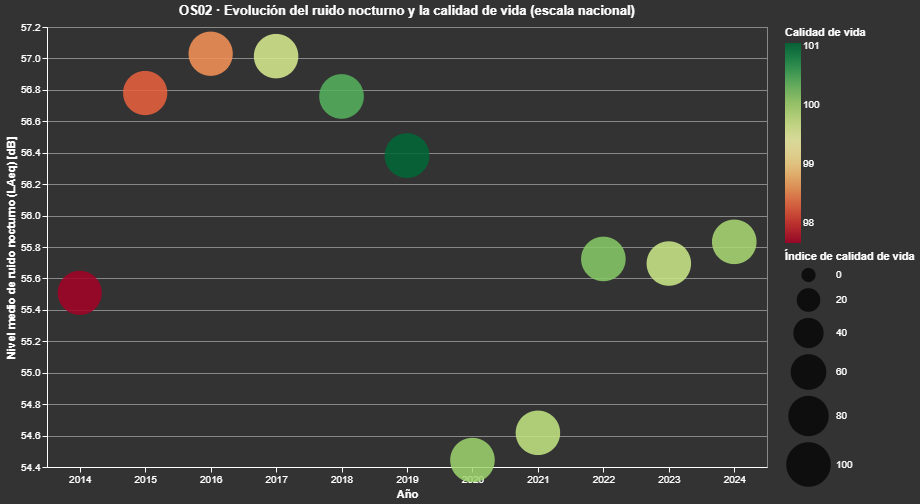

In [24]:
# Visualización OS02‑A01 (Scatter plot)
# X → Exposición al ruido (LAeq nocturno medio anual)
# Y → Índice de calidad de vida nacional
# Punto → un año
# Tooltip → año + valores exactos

# Calcular explícitamente el rango del índice de calidad de vida
min_cv = df_os02_a01["indice_calidad_vida"].min()
max_cv = df_os02_a01["indice_calidad_vida"].max()

scatter_os02_a01_time_color = (
    alt.Chart(df_os02_a01)
    .mark_circle(opacity=0.85)
    .encode(
        x=alt.X("año:O", title="Año", axis=alt.Axis(labelAngle=0)),
        y=alt.Y("laeq_nocturno:Q", title="Nivel medio de ruido nocturno (LAeq) [dB]", scale=alt.Scale(zero=False)),
        size=alt.Size("indice_calidad_vida:Q", title="Índice de calidad de vida", scale=alt.Scale(range=[200, 2000])),
        color=alt.Color("indice_calidad_vida:Q", title="Índice de calidad de vida", scale=alt.Scale(scheme="redyellowgreen",
                domain=[min_cv, max_cv]  # ⬅ control explícito
            ),
            legend=alt.Legend(title="Calidad de vida", orient="right")
        ),
        tooltip=[
            alt.Tooltip("año:O", title="Año"),
            alt.Tooltip("laeq_nocturno:Q", title="LAeq nocturno [dB]", format=".2f"),
            alt.Tooltip("indice_calidad_vida:Q", title="Índice de calidad de vida", format=".2f")
        ]
    )
    .properties(
        width=720, height=440,
        title="OS02 · Evolución del ruido nocturno y la calidad de vida (escala nacional)"
    )
)

scatter_os02_a01_time_color

CONCLUSIONES DE LA VISUALIZACION OS02-a01: 
Los años con mayor exposición media al ruido nocturno tienden a asociarse con valores más bajos del índice agregado de calidad de vida, sugiriendo una relación negativa entre presión acústica y bienestar.

VISUALIZACIÓN OS02-A02: Evolución temporal: ruido vs bienestar (Madrid)
Tipo: Small multiples / líneas sincronizadas
Datasets:
* Ruido: df_01_daily_plot
* Bienestar Madrid: df_07_Mad_Q_vida
Columnas usadas:
Ruido: fecha, NMT, laeq. Se agregan media anual de laeq (promedio de estaciones)
Bienestar Madrid: columnas 2008 … 2024, hoja (dimensiones)

Diseño:
Gráfico 1: evolución del ruido medio anual
Gráfico 2: evolución índice de bienestar Madrid
Eje X compartido (año)

Hipótesis: Las variaciones en la presión acústica a lo largo del tiempo coinciden con cambios en los indicadores de bienestar en la Comunidad de Madrid.

In [25]:
#Obtenermos el ruido medio anual en madrid, promediando todas las estaciones.

# Asegurar formato fecha
df_01_daily_plot["fecha"] = pd.to_datetime(df_01_daily_plot["fecha"])

# ---- RUIDO: media anual de LAeq (promedio de estaciones) ----
df_ruido_madrid_anual = (
    df_01_daily_plot
    .assign(año=lambda d: d["fecha"].dt.year)
    .groupby("año", as_index=False)
    .agg(laeq_medio=("laeq", "mean"))
)

df_ruido_madrid_anual.head()

,año,laeq_medio
0,2014,59.652561
1,2015,60.824524
2,2016,60.895810
3,2017,60.885756
4,2018,60.637140


In [26]:
#Calculamos el bienestar en Madrid. Para obtener la evolulción temporal del índice de calidad de vida por dimensiones
# ---- BIENESTAR MADRID en formato largo ----
df_bienestar_madrid_long = (
    df_07_Mad_Q_vida
    .drop(columns=["CCAA"])
    .rename(columns={"hoja": "dimension"})
    .melt(
        id_vars="dimension",
        var_name="año",
        value_name="indice_calidad_vida"
    )
)

df_bienestar_madrid_long["año"] = df_bienestar_madrid_long["año"].astype(int)

df_bienestar_madrid_long.head()

,dimension,año,indice_calidad_vida
0,Dimensión 1,2008,99.281388
1,Dimensión 2,2008,102.443179
2,Dimensión 3,2008,103.489366
3,Dimensión 4,2008,104.808559
4,Dimensión 5,2008,101.086655


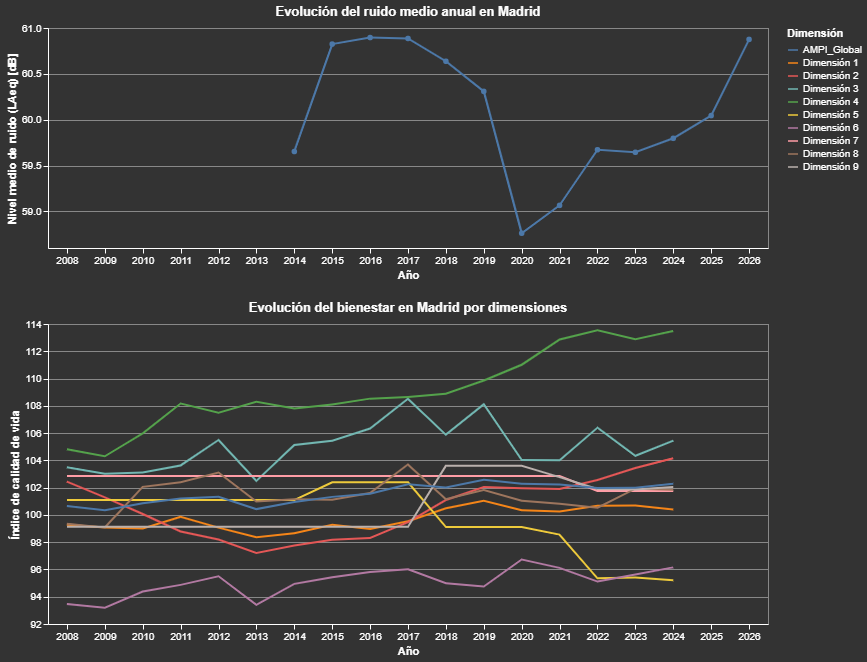

In [27]:
#VISUALIZACIÓN OS02-A02: Dos gráficos. 
#(1) Ruiedo medio anual en Madrid.
#(2) Evolución del bienestar por dimensiones

# -------------------------
# Gráfico 1: Ruido medio anual
# -------------------------
chart_ruido = (
    alt.Chart(df_ruido_madrid_anual).mark_line(point=True)
    .encode(
        x=alt.X("año:O", title="Año", axis=alt.Axis(labelAngle=0)),
        y=alt.Y("laeq_medio:Q", title="Nivel medio de ruido (LAeq) [dB]", scale=alt.Scale(zero=False)),
        tooltip=[
            alt.Tooltip("año:O", title="Año"),
            alt.Tooltip("laeq_medio:Q", title="LAeq medio", format=".2f")
        ]
    )
    .properties(width=720, height=220, title="Evolución del ruido medio anual en Madrid")
)

# -------------------------
# Gráfico 2: Bienestar Madrid (por dimensiones)
# -------------------------
chart_bienestar = (
    alt.Chart(df_bienestar_madrid_long)
    .mark_line()
    .encode(
        x=alt.X("año:O", title="Año", axis=alt.Axis(labelAngle=0)),
        y=alt.Y("indice_calidad_vida:Q", title="Índice de calidad de vida", scale=alt.Scale(zero=False)),
        color=alt.Color("dimension:N", title="Dimensión"),
        tooltip=[
            alt.Tooltip("dimension:N", title="Dimensión"),
            alt.Tooltip("año:O", title="Año"),
            alt.Tooltip("indice_calidad_vida:Q", title="Índice", format=".2f")
        ]
    )
    .properties(width=720, height=300, title="Evolución del bienestar en Madrid por dimensiones")
)

# -------------------------
# Visualización final OS02-A02
# -------------------------
vis_os02_a02 = alt.vconcat(chart_ruido, chart_bienestar).resolve_scale(x="shared")

vis_os02_a02

In [40]:
#LITERALES DE LAS DIMENSIONES
#Las dimensiones del bienestar se identifican mediante sus literales completos (salud, educación, trabajo, etc.), 
#extraídos directamente del dataset de evolución del índice de calidad de vida.
dimensiones_literales = (df_07_evo_Q_vida["dim"].dropna().unique().tolist())
dimensiones_literales

['Global',
 '1. Condiciones materiales de vida',
 '2. Trabajo',
 '3. Salud',
 '4. Educación',
 '5. Ocio y relaciones sociales',
 '6. Seguridad física y personal',
 '7. Gobernanza y derechos básicos',
 '8. Entorno y medioambiente',
 '9. Experiencia general de la vida']

## (B) - Análisis de ruido Ambiental según normativa: Ruido como factor de riesgo para la salud Utilizaremos:

Ruido nocturno (ln)
Límites legales (df_03_noise_lim)

VISUALIZACIÓN OS02-B01: Ruido nocturno y superación de límites de salud
Tipo: Bar chart o heatmap
Datasets:
* Ruido: df_02_cont_acustic
* Normativa: df_03_noise_lim
Columnas usadas:
Ruido: ln, fecha, estacion. Se agregan media anual de ln y % de registros que superan el límite nocturno
Normativa: noiselevelindicator = lnight, limitvalue

Diseño: El color en heatmap indica intensidad de superación.
Hipótesis: El ruido nocturno supera con mayor frecuencia los umbrales recomendados para la salud, lo que refuerza su potencial impacto negativo sobre el bienestar.

In [41]:
#recuperamos el valor de límite nocturno según la normativa. 
#Se obtiene de df_03_noise_lim
# -----------------------------------
# LÍMITE NOCTURNO (Ln) SEGÚN NORMATIVA
# -----------------------------------
limite_ln = (
    df_03_noise_lim
    .query("noiselevelindicator == 'lnight' and limitvaluedefined_bool == True")
    ["limitvalue"]
    .iloc[0]
)

limite_ln

np.float64(50.0)

LIMITE NOCTURNO = 50dB

In [42]:
# -----------------------------------
# RUIDO NOCTURNO PROCESADO
# -----------------------------------
df_02_cont_acustic["fecha"] = pd.to_datetime(df_02_cont_acustic["fecha"])

df_ruido_ln = (df_02_cont_acustic.dropna(subset=["ln"]).assign(año=lambda d: d["fecha"].dt.year,
        supera_limite=lambda d: d["ln"] > limite_ln ))

# Agregación anual
df_ln_anual = (df_ruido_ln.groupby("año", as_index=False)
    .agg(ln_medio=("ln", "mean"), pct_superacion=("supera_limite", "mean") )
)

# Pasamos a porcentaje
df_ln_anual["pct_superacion"] *= 100

df_ln_anual.head()

,año,ln_medio,pct_superacion
0,2015,57.257097,90.000000
1,2016,57.769086,91.129032
2,2017,57.706486,91.891892
3,2018,57.444355,92.204301
4,2019,57.098922,91.913747


In [44]:
# Diseño del Heatmap (OS02‑B01)
#Codificación visual: Eje X → Año. Eje Y → Métrica acústica
# Ln medio % superación del límite

# Color → Intensidad del problema (más oscuro = peor)
# Tooltip → valores exactos

# -----------------------------------
# FORMATO LARGO PARA HEATMAP
# -----------------------------------
df_ln_heatmap = df_ln_anual.melt(id_vars="año", value_vars=["ln_medio", "pct_superacion"],
    var_name="métrica", value_name="valor")

# Etiquetas legibles
df_ln_heatmap["métrica"] = df_ln_heatmap["métrica"].map({
    "ln_medio": "Ln medio [dB]", "pct_superacion": "% de superación del límite"
})

df_ln_heatmap.head()

,año,métrica,valor
0,2015,Ln medio [dB],57.257097
1,2016,Ln medio [dB],57.769086
2,2017,Ln medio [dB],57.706486
3,2018,Ln medio [dB],57.444355
4,2019,Ln medio [dB],57.098922


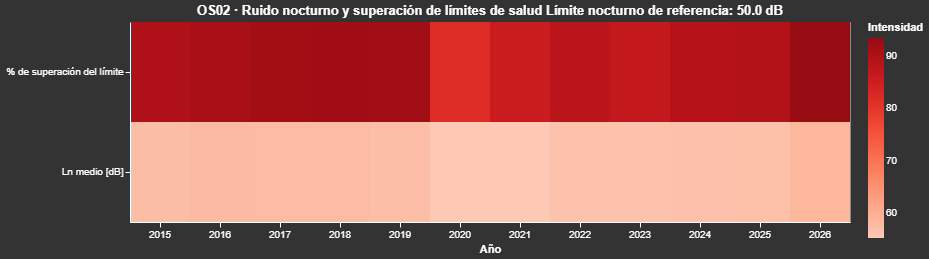

In [54]:
heatmap_os02_b01 = (
    alt.Chart(df_ln_heatmap)
    .mark_rect()
    .encode(
        x=alt.X(
            "año:O",
            title="Año",
            axis=alt.Axis(labelAngle=0)
        ),
        y=alt.Y(
            "métrica:N",
            title=""
        ),
        color=alt.Color(
            "valor:Q",
            title="Intensidad",
            scale=alt.Scale(scheme="reds")
        ),
        tooltip=[
            alt.Tooltip("año:O", title="Año"),
            alt.Tooltip("métrica:N", title="Indicador"),
            alt.Tooltip("valor:Q", title="Valor", format=".2f")
        ]
    )
    .properties(
        width=720,
        height=200,
        title=(
            "OS02 · Ruido nocturno y superación de límites de salud\n"
            f"Límite nocturno de referencia: {limite_ln} dB"
        )
    )
)

heatmap_os02_b01

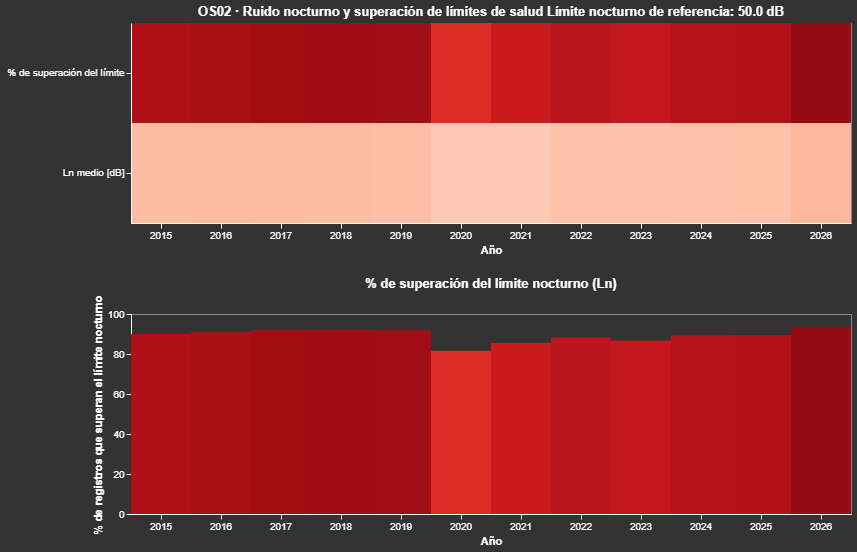

In [55]:
#Bar chart: % de superación del límite nocturno
# usando el valor calculado %: df_ln_anual["pct_superacion"]

bars_os02_b01 = (
    alt.Chart(df_ln_anual)
    .mark_bar()
    .encode(
        x=alt.X(
            "año:O",
            title="Año",
            axis=alt.Axis(labelAngle=0)
        ),
        y=alt.Y(
            "pct_superacion:Q",
            title="% de registros que superan el límite nocturno",
            scale=alt.Scale(domain=[0, 100])
        ),
        color=alt.Color(
            "pct_superacion:Q",
            scale=alt.Scale(scheme="reds"),
            legend=None
        ),
        tooltip=[
            alt.Tooltip("año:O", title="Año"),
            alt.Tooltip(
                "pct_superacion:Q",
                title="% superación",
                format=".1f"
            )
        ]
    )
    .properties(
        width=720,
        height=200,
        title="% de superación del límite nocturno (Ln)"
    )
)

vis_os02_b01 = alt.vconcat(
    heatmap_os02_b01,
    bars_os02_b01
).resolve_scale(x="shared")

vis_os02_b01

En la visualización OS02‑B01, tanto el nivel medio de ruido nocturno como el porcentaje de registros que superan el límite sanitario recomendado se representan mediante una escala cromática en tonos rojos. Esta elección refuerza la lectura conjunta del fenómeno, enfatizando la persistencia y la intensidad de la superación de los umbrales nocturnos asociados a potenciales efectos adversos sobre la salud.

VISUALIZACIÓN OS02-B02: Bienestar por dimensiones vs ruido
Tipo: Heatmap
Datasets:
* df_07_evo_long_Q_vida
* Ruido agregado anual (df_01_daily)
Columnas usadas:
Bienestar: dim, año, valor_evolucion
Diseño: 
Eje X → año
Eje Y → dimensión (Salud, Entorno, Educación…)
Color → según el valor del índice
Se mostrarán años de mayor ruido.
   #
  Hipótesis: Las dimensiones relacionadas con salud y entorno muestran mayor sensibilidad frente a contextos de mayor exposición acústica.
  Objetivo: explorar cómo evolucionan las dimensiones del bienestar en el tiempo y destacar los años con mayor exposición acústica, para apoyar la hipótesis de sensibilidad de salud y entorno al ruido.

In [63]:
#Preparación de los datos
#Bienestar – df_07_evo_long_Q_vida: Columnas disponibles (ya en formato largo):
# * dim → literal de la dimensión (Salud, Educación, Trabajo…)
# * año
# * valor_evolucion

df_bienestar = df_07_evo_long_Q_vida.copy()

# Ruido agregado anual – df_01_daily
# Columnas utilizadas: fecha, periodo, laeq

# Decisión metodológica según el OS02: 
# * Usamos ruido nocturno (periodo == 'N')
# * Calculamos media anual
# * Identificamos años de mayor ruido (percentil 75)

# Asegurar formato fecha
df_01_daily["fecha"] = pd.to_datetime(df_01_daily["fecha"])

# Ruido nocturno anual
df_ruido_anual = (
    df_01_daily
    .query("periodo == 'N'")
    .assign(año=lambda d: d["fecha"].dt.year)
    .groupby("año", as_index=False)
    .agg(laeq_nocturno=("laeq", "mean"))
)

# Umbral de años con mayor ruido (percentil 75)
umbral_ruido = df_ruido_anual["laeq_nocturno"].quantile(0.75)

df_ruido_anual["alto_ruido"] = df_ruido_anual["laeq_nocturno"] >= umbral_ruido

df_ruido_anual.head()

,año,laeq_nocturno,alto_ruido
0,2014,55.508328,False
1,2015,56.779824,True
2,2016,57.029914,True
3,2017,57.014522,True
4,2018,56.758120,False


In [74]:
#2️ Visualización base: Heatmap de bienestar
# Eje X → Año. Eje Y → Dimensión de bienestar (literal). Color → Valor del índice (valor_evolucion)

heatmap_bienestar = (
    alt.Chart(df_bienestar)
    .mark_rect()
    .encode(
        x=alt.X(
            "año:O",
            title="Año",
            axis=alt.Axis(labelAngle=0)
        ),
        y=alt.Y(
            "dim:N",
            title="Dimensión de bienestar"
        ),
        color=alt.Color(
            "valor_evolucion:Q",
            title="Índice de bienestar",
            scale=alt.Scale(scheme="redyellowgreen")
        ),
        tooltip=[
            alt.Tooltip("dim:N", title="Dimensión"),
            alt.Tooltip("año:O", title="Año"),
            alt.Tooltip(
                "valor_evolucion:Q",
                title="Índice",
                format=".2f"
            )
        ]
    )
    .properties(
        width=720,
        height=300,
        title="OS02 · Evolución del bienestar por dimensiones"
    )
)

In [75]:
# Señalización de años con mayor ruido
# Para mostrar los años de mayor ruido, añadimos líneas verticales sobre esos años.

lineas_ruido = (
    alt.Chart(df_ruido_anual[df_ruido_anual["alto_ruido"]])
    .mark_rule(color="red", strokeDash=[4, 2], opacity=0.7)
    .encode(
        x="año:O",
        tooltip=[
            alt.Tooltip("año:O", title="Año"),
            alt.Tooltip(
                "laeq_nocturno:Q",
                title="LAeq nocturno",
                format=".2f"
            )
        ]
    )
)

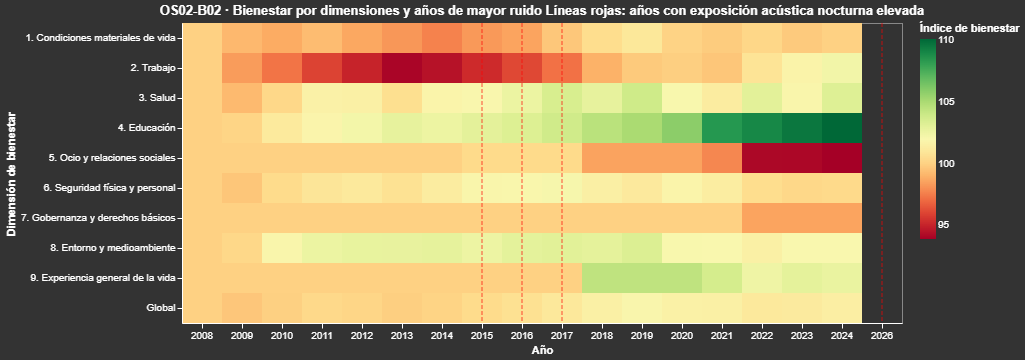

In [76]:
#VISUALIZACIÓN FINAL: VIS_OS02_B02
vis_os02_b02 = (
    heatmap_bienestar + lineas_ruido
).properties(
    title=(
        "OS02‑B02 · Bienestar por dimensiones y años de mayor ruido\n"
        "Líneas rojas: años con exposición acústica nocturna elevada"
    )
)

vis_os02_b02


El heatmap OS02‑B02 muestra la evolución temporal de las distintas dimensiones del bienestar, mientras que las líneas verticales señalan los años con mayor exposición acústica nocturna. Esta combinación permite explorar si dimensiones como salud y entorno presentan variaciones más acusadas en contextos de mayor ruido, apoyando la hipótesis de una mayor sensibilidad del bienestar a la presión acústica.